# XGBoost for Yield Prediction
This notebook implements the final XGBoost model for the ML Hackathon.

In [1]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

# --- PATH CONFIGURATION ---
# Set this to True if you are running in Google Colab
RUNNING_IN_COLAB = True

if RUNNING_IN_COLAB:
    # By default, Colab uploads go to the current directory (/content/)
    TRAIN_PATH = 'train_dataset.csv'
    TEST_PATH = 'test_dataset.csv'
    PREDS_DIR = '.'
else:
    # Default local paths
    TRAIN_PATH = '../datasets/train_dataset.csv'
    TEST_PATH = '../datasets/test_dataset.csv'
    PREDS_DIR = '../predictions'

os.makedirs(PREDS_DIR, exist_ok=True)


In [3]:
# Load datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

def engineer_features(df):
    df = df.copy()
    # 1. Residence-Time Proxy
    df['residence_proxy'] = df['length_m'] / df['flow_rate_L_min']
    # 2. Mean Temperature
    df['mean_T'] = (df['inlet_temperature_K'] + df['jacket_temperature_K']) / 2
    return df

# Apply feature engineering
X_train_full = engineer_features(train_df.drop(columns=['overall_yield']))
y_train_full = train_df['overall_yield']
X_test = engineer_features(test_df)

print(f"Training features shape: {X_train_full.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (150, 7)
Testing features shape: (50, 7)


In [4]:
# Define the XGBoost model
xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5,
    random_state=42
)

# Cross Validation
rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
rmse_scores = []

for train_idx, val_idx in rkf.split(X_train_full):
    X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

    # Train
    xgb.fit(X_tr, y_tr)

    # Predict
    y_pred = xgb.predict(X_val)

    # Clip predictions to physical bounds [0, 100]
    y_pred_clipped = np.clip(y_pred, 0, 100)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_clipped))
    rmse_scores.append(rmse)

print(f"Repeated CV RMSE: {np.mean(rmse_scores):.4f} +/- {np.std(rmse_scores):.4f}")

Repeated CV RMSE: 19.0110 +/- 3.2937


In [5]:
# Train on full dataset
print("Training final model on full dataset...")
xgb.fit(X_train_full, y_train_full)

# Predict on test set
y_test_pred = xgb.predict(X_test)

# Apply physical constraints
y_test_pred_clipped = np.clip(y_test_pred, 0, 100)

# Prepare submission
submission = pd.DataFrame({
    'overall_yield': np.round(y_test_pred_clipped, 3)
})

# Save predictions
submission_path = f'{PREDS_DIR}/xgboost_pred2.csv'
submission.to_csv(submission_path, index=False)
print(f"\nPredictions saved to {submission_path}")

# Display a few predictions
print("\nSample Predictions:")
for i in range(5):
    print(f"Test case {i+1}: Yield = {y_test_pred_clipped[i]:.2f}%")

Training final model on full dataset...

Predictions saved to ./xgboost_pred2.csv

Sample Predictions:
Test case 1: Yield = 21.46%
Test case 2: Yield = 90.37%
Test case 3: Yield = 1.95%
Test case 4: Yield = 68.73%
Test case 5: Yield = 13.37%


## Visualizations
The following plots help visualize the model's behavior and are highly recommended for the Phase 2 pitch.

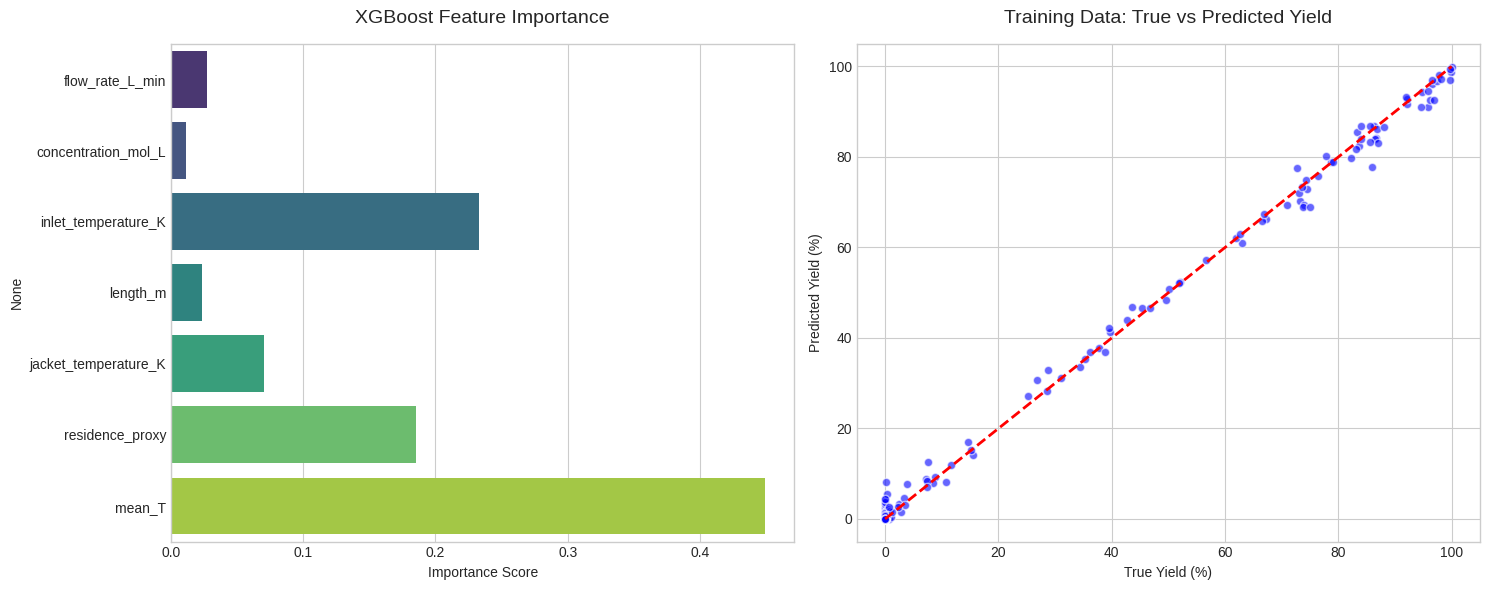

In [6]:
# Visualization: Feature Importance and True vs Predicted
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Feature Importance
importance = xgb.feature_importances_
features = X_train_full.columns
sns.barplot(x=importance, y=features, ax=axes[0], palette='viridis')
axes[0].set_title('XGBoost Feature Importance', fontsize=14, pad=15)
axes[0].set_xlabel('Importance Score')

# 2. Training Fit (True vs Predicted)
y_train_pred = np.clip(xgb.predict(X_train_full), 0, 100)
axes[1].scatter(y_train_full, y_train_pred, alpha=0.6, color='b', edgecolor='w')
axes[1].plot([0, 100], [0, 100], 'r--', lw=2) # Perfect prediction line
axes[1].set_title('Training Data: True vs Predicted Yield', fontsize=14, pad=15)
axes[1].set_xlabel('True Yield (%)')
axes[1].set_ylabel('Predicted Yield (%)')

plt.tight_layout()
plt.show()
